<a href="https://colab.research.google.com/github/dev226004-boop/Learning/blob/main/Content_Writer_Week_5_Multi_Agents_Systems_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-Agent Content Writer — LangGraph Assignment**

## **Problem Statement**

Build a **multi-agent system** using LangGraph that acts as a smart content assistant. The system should have a **router** that reads the user's request and sends it to the right agent:

- **SEO Blog Writer** — writes long-form blog posts, uses research & keyword tools autonomously
- **X/Twitter Writer** — writes short tweets (<280 chars), uses trending topic tools autonomously
- **General Handler** — answers everything else (greetings, questions, etc.) using conversation memory

The system must support **tool-calling loops** (agent calls a tool → gets result → decides to call another tool or finish) and **persistence** (remembers past conversations using a checkpointer so follow-up questions like "what was my last request?" work).

### Architecture

```
                 ┌→ SEO Blog Writer ↔ tools (loop)
User → Router ───┼→ X/Twitter Writer ↔ tools (loop)
                 └→ General Handler → END
```

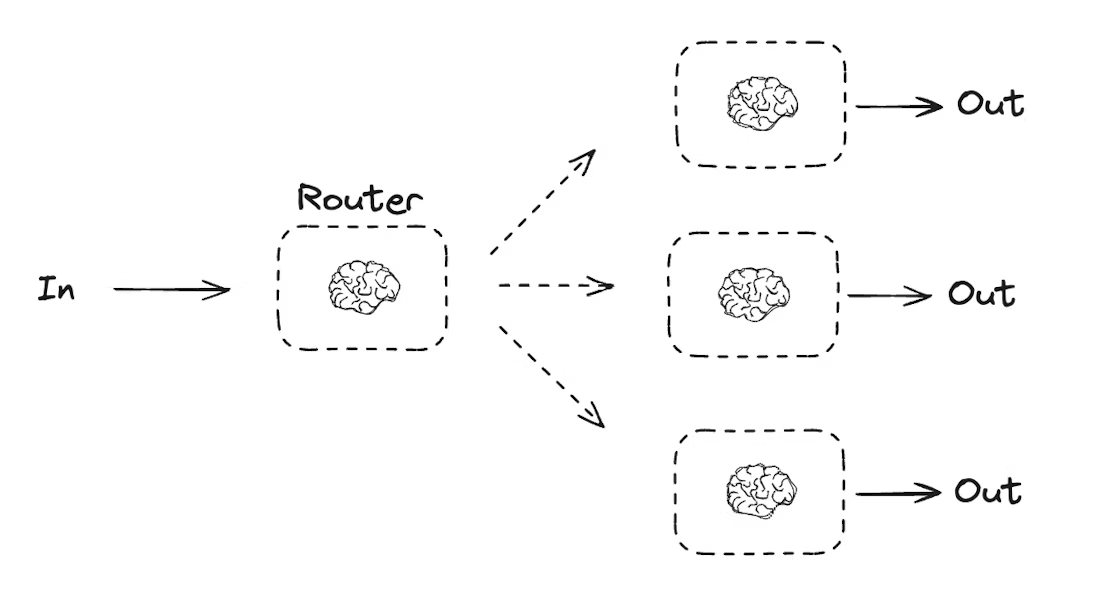




## **💡Tips**

You don't have to use mock data — you can make your tools actually work!

`research_tool` → Use a Deep Research agent (Tavily Deep Search, Perplexity API) to fetch real articles, papers, and references. These calls are heavier and costlier, so design your agent to call this once or twice for in-depth content gathering — not repeatedly.

---


`internet_search_tool` → Use SerpAPI, Google Custom Search API, or Tavily basic search for quick lookups like SEO keywords, trending topics, and hashtags. These are lighter and cheaper, so it's okay if the agent calls this multiple times.


---


**Think about cost-efficiency:** In your agent's system prompt, guide it on when to use which tool — e.g., "Use research_tool first to gather deep content, then use internet_search_tool for SEO keywords and trends. Avoid calling research_tool always." This is how real-world agents are designed — you control tool usage through smart prompting, not just by giving access.


## **Steps**




### Step 1: Setup
Install `langgraph`, `langchain`, `langchain-openai`. Configure your LLM.


In [27]:

! pip install -q -U langgraph langchain langchain-openai deepagents
!pip install -q  tavily-python langchain-tavily
from typing import Literal
from tavily import TavilyClient

In [18]:
# API keys and shared chat model
# OPENAI_API_KEY powers the language model.
# TAVILY_API_KEY powers the web-search tool used by the research agent.

import getpass
import os
from google.colab import userdata

def load_secret(name: str) -> str:
    try:
        value = userdata.get(name)
        if value:
            return value
    except Exception:
        pass
    return getpass.getpass(f"Enter {name}: ")

os.environ["OPENAI_API_KEY"] = load_secret("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = load_secret("TAVILY_API_KEY")

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5",
    temperature=0.2,
)

### Step 2: Define State
Create a shared `TypedDict` with: `user_input`, `route`, `output`, `messages`. Use `add_messages` reducer on messages.



In [19]:
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class CopyWriter(TypedDict):
  user_input: str           # The original user request
  route: Literal["seo_blog_writer", "x_blog_writer", "general"]  # Router's decision
  output: str               # Final output from the selected agent
  messages: Annotated[list[BaseMessage], add_messages]

# Step 3: Router Node
Classifies input into `seo_blog_writer` / `x_blog_writer` / `general`. Returns only one word. Also persists user input into messages.



In [20]:
# Router node
# Purpose:
# - Look at the user's request
# - Decide which specialist should handle it
# - Save the user message into state["messages"] for memory

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

router_instructions = """
You route requests.

Return seo_blog_writer for blog posts or long articles.
Return x_blog_writer for tweets, X posts, or short social posts.
Return general for normal questions or greetings.

Return only one label.
"""

def router_node(state: CopyWriter):
    messages = [
        SystemMessage(content=router_instructions),
        HumanMessage(content=state["user_input"])
    ]

    result = llm.invoke(messages)
    route = result.content.strip().lower()

    # Defensive cleanup in case the model returns a synonym.
    if route not in ["seo_blog_writer", "x_blog_writer", "general"]:
        route = "general"

    return {
        "route": route,
        "messages": [HumanMessage(content=state["user_input"])]
    }

In [21]:
# Test the router
test_cases = [
    "Hi, how are you?",
    "Write a detailed blog post about AI in healthcare",
    "Write a tweet about our new product launch",
    "Create an in-depth article on climate change",
    "Make a short X post announcing our funding round",
    "Hi, how are you?",
]
for test in test_cases:
    state = {"user_input": test, "route": "", "output": ""}
    result = router_node(state)
    print(f"Input: {test}\nRoute: {result['route']}\n")

Input: Hi, how are you?
Route: general

Input: Write a detailed blog post about AI in healthcare
Route: seo_blog_writer

Input: Write a tweet about our new product launch
Route: x_blog_writer

Input: Create an in-depth article on climate change
Route: seo_blog_writer

Input: Make a short X post announcing our funding round
Route: x_blog_writer

Input: Hi, how are you?
Route: general



 **General Node**

In [22]:
# General node — router handles it directly

def general_node(state: CopyWriter):
    # Build conversation history from persisted messages
    history = state.get("messages", [])

    system = SystemMessage(content="""You are a helpful assistant. You have access to the full conversation history.
    Answer the user's question briefly and clearly using context from previous messages if relevant.
    Let them know you specialize in SEO blog writing and X/Twitter post writing if they need content.""")

    # Add current user input to history
    messages = [system] + history + [HumanMessage(content=state["user_input"])]

    result = llm.invoke(messages)

    # Save to messages so checkpointer persists it
    return {
        "output": result.content,
        "messages": [
            HumanMessage(content=state["user_input"]),
            AIMessage(content=result.content)
        ]
    }

### Step 4: Tools and the Deep Research Agent

Create a lightweight `internet_search_tool` using Tavily. Then create a separate Deep Agent that can call that search tool repeatedly, plan its research, and summarize its findings. Finally, wrap the Deep Agent inside `research_tool` so the outer SEO writer sees it as one normal LangChain tool.

The nesting is:

```text
SEO writer → research_tool → Deep Agent → internet_search_tool
```

The X/Twitter writer still receives only the lightweight search tool and never posts anything.

In [38]:
# Tools
# Purpose:
# - internet_search_tool performs one quick web search.
# - research_tool performs one broader search using the same search tool.
# - Neither tool creates another agent loop.

from langchain_core.tools import tool
from tavily import TavilyClient

tavily_client = TavilyClient(
    api_key=os.environ["TAVILY_API_KEY"]
)


@tool
def internet_search_tool(query: str) -> str:
    """Search the web for quick, current information."""

    response = tavily_client.search(
        query=query,
        search_depth="basic",
        max_results=3,
    )

    lines = []

    for item in response.get("results", []):
        lines.append(
            f"- {item.get('title', 'Untitled')}\n"
            f"  {item.get('content', '')}\n"
            f"  Source: {item.get('url', '')}"
        )

    return "\n".join(lines) or "No search results found."


@tool
def research_tool(topic: str) -> str:
    """Gather useful background research about a topic."""

    return internet_search_tool.invoke(
        {
            "query": (
                f"{topic}. Find key facts, recent developments, "
                f"important examples, and practical insights."
            )
        }
    )


seo_tools = [
    research_tool,
    internet_search_tool,
]

x_tools = [
    internet_search_tool,
]

### Step 5: SEO Blog Writer

Bind both outer tools to the SEO writer. `research_tool` starts the inner Deep Agent; `internet_search_tool` performs a single lightweight lookup. The outer LangGraph tool loop remains responsible for returning tool results to the SEO writer.


In [39]:
# SEO Blog Writer node
# Purpose:
# - The writer decides whether it needs deep research or a quick search.
# - LangGraph handles the outer writer → tool → writer loop.
# - The Deep Agent handles its own internal research loop.

seo_llm = llm.bind_tools(seo_tools)

seo_system_prompt = """
You are an SEO blog writer.
Use research_tool once when background research is needed.
Use internet_search_tool for quick keywords or trends.
Write a useful blog with a title, headings, conclusion, and CTA.
"""

def seo_blog_writer_node(state: CopyWriter):
    messages = [
        SystemMessage(content=seo_system_prompt),
        *state.get("messages", [])
    ]

    response = seo_llm.invoke(messages)

    return {
        "messages": [response],
        "output": response.content
    }


In [40]:
# Optional quick test of the mock tool
internet_search_tool.invoke({"query": "AI agents for small businesses"})

"- AI agents for small businesses: Benefits & examples\n  ![Image 3: AI agents for small businesses: Benefits, use cases, and how to choose the best one ](https://sb.nordcdn.com/transform/2c7c6ec0-77d5-468f-aa68-879c0df67c38/nexos-blog-social-image-9-1200x628). *   [What are AI agents for small businesses?](https://nexos.ai/blog/ai-agents-for-small-businesses#what-are-ai-agents-for-small-businesses). *   [The benefits of AI agents for small businesses](https://nexos.ai/blog/ai-agents-for-small-businesses#the-benefits-of-ai-agents-for-small-businesses). *   [Reduced workload](https://nexos.ai/blog/ai-agents-for-small-businesses#reduced-workload). *   [Lower operating costs](https://nexos.ai/blog/ai-agents-for-small-businesses#lower-operating-costs). *   [Improved efficiency](https://nexos.ai/blog/ai-agents-for-small-businesses#improved-efficiency). *   [Better decision-making with data](https://nexos.ai/blog/ai-agents-for-small-businesses#better-decision-making-with-data). *   [Scalabil

In [41]:
# Optional quick test of the mock tool
#research_tool.invoke({"topic": "AI agents for small businesses"})
# Optional focused test before building the full graph
# This invokes the Deep Agent through the outer research tool.
research_tool.invoke({"topic": "How AI agents help software engineers learn"})

'- Using AI Agents in Software Development 2026 - Overcommitted\n  They discuss the impact of AI tools like Copilot and Claude Code on programmer productivity and software engineering workflows. The hosts\n  Source: https://overcommitted.dev/using-ai-agents-in-software-development-2026-current-uses-and-future-possibilities\n- Research Paper: AI Agents and the ReAct Pattern - YouTube\n  Comments ; The Current State of AI for Software Engineers (2026). Gaurav Sen · 15K views ; AI Engineering Paper #4: Mixture of Experts. Gaurav Sen\n  Source: https://www.youtube.com/watch?v=wSyAMV9B2gc\n- Role of AI Agents in Software Engineering Intelligence - Hivel.ai\n  AI Agents bridge these two (SDLC and SEI) by analyzing patterns on scale and providing real-time, data-backed decisions across the lifecycle.\n  Source: https://www.hivel.ai/blog/ai-agents-in-software-engineering-intelligence'

### Step 6: X/Twitter Writer
Bind only `internet_search_tool`. Same loop pattern. Writes short posts with emojis and hashtags.



In [42]:
# X/Twitter Writer node
# Purpose:
# - This agent only gets the lightweight internet_search_tool.
# - It does NOT post anything.
# - It only prepares tweet text under 280 characters.

x_llm = llm.bind_tools(x_tools)

x_system_prompt = """
You write X/Twitter posts.
Use the search tool if helpful.
Do not post anything.
Return only the tweet text.
Keep it under 280 characters.
Use 0-2 emojis and 1-3 hashtags.
"""

def x_blog_writer_node(state: CopyWriter):
    messages = [
        SystemMessage(content=x_system_prompt),
        *state.get("messages", [])
    ]

    response = x_llm.invoke(messages)

    return {
        "messages": [response],
        "output": response.content
    }

### Step 7: General Handler
Uses full message history from state to answer general queries with context. Saves both user and AI messages for persistence.



In [43]:
# General Handler node
# Purpose:
# - Handles greetings, normal questions, and memory questions.
# - It does not use tools.
# - It saves the assistant response back into messages.

def general_node(state: CopyWriter):
    system = SystemMessage(content="""
You are a helpful assistant.
Use the conversation history if relevant.
Answer briefly and clearly.
""")

    messages = [
        system,
        *state.get("messages", [])
    ]

    response = llm.invoke(messages)

    return {
        "messages": [response],
        "output": response.content
    }

### Step 8: Build Graph
Add all nodes. Router → 3-way conditional edges. Agent ↔ tool loops using `should_continue` functions. General → END.



In [44]:
# Build Graph
# Purpose:
# - Router chooses the first specialist.
# - Writer agents can either finish or call tools.
# - Tool results go back to the same writer so it can continue.

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(CopyWriter)

# Main nodes
builder.add_node("router", router_node)
builder.add_node("seo_blog_writer", seo_blog_writer_node)
builder.add_node("x_blog_writer", x_blog_writer_node)
builder.add_node("general", general_node)

# Tool nodes
builder.add_node("seo_tools", ToolNode(seo_tools))
builder.add_node("x_tools", ToolNode(x_tools))

# Start with router
builder.add_edge(START, "router")

# Router chooses one path
def route_decision(state: CopyWriter):
    return state["route"]

builder.add_conditional_edges(
    "router",
    route_decision,
    {
        "seo_blog_writer": "seo_blog_writer",
        "x_blog_writer": "x_blog_writer",
        "general": "general",
    },
)

# SEO tool loop:
# If the SEO writer called a tool, go to seo_tools.
# Otherwise, end.
builder.add_conditional_edges(
    "seo_blog_writer",
    tools_condition,
    {
        "tools": "seo_tools",
        END: END,
    },
)
builder.add_edge("seo_tools", "seo_blog_writer")

# X/Twitter tool loop:
# If the X writer called a tool, go to x_tools.
# Otherwise, end.
builder.add_conditional_edges(
    "x_blog_writer",
    tools_condition,
    {
        "tools": "x_tools",
        END: END,
    },
)
builder.add_edge("x_tools", "x_blog_writer")

# General answers directly
builder.add_edge("general", END)

### Step 9: Persistence
Add `MemorySaver` checkpointer. Compile graph. Pass `thread_id` in config on every call.


In [45]:
# Persistence
# Purpose:
# - MemorySaver stores conversation state by thread_id.
# - Use the same thread_id for follow-up questions.
# - Use a different thread_id for a separate conversation.

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

config = {
    "configurable": {
        "thread_id": "content-writer-demo"
    }
}

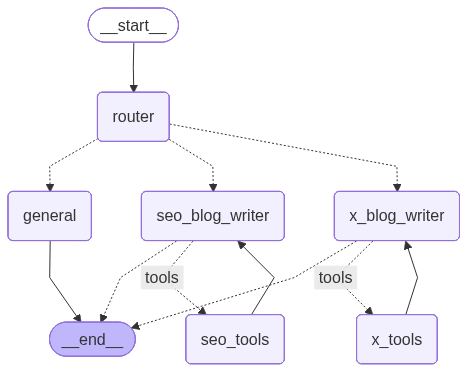

In [47]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

### Step 10: Test
- Test all 3 routes work correctly

In [46]:
# Test
# Purpose:
# - These examples verify all 3 routes.
# - The X/Twitter route only prepares tweet text. It does not tweet.

def run_agent(user_input: str):
    result = graph.invoke(
        {
            "user_input": user_input,
            "messages": [],
            "route": "general",
            "output": "",
        },
        config=config,
    )

    print("USER:", user_input)
    print("ROUTE:", result["route"])
    print("OUTPUT:\n", result["output"])
    print("-" * 80)

# 1) General route
run_agent("Hi, what can you help me with?")

# 2) X/Twitter writer route
run_agent("Write a tweet about AI agents helping software engineers learn faster.")

# 3) SEO blog writer route
run_agent("Write a detailed SEO blog post about AI agents for productivity.")

# 4) Memory check using same thread_id
run_agent("What was my last request?")

USER: Hi, what can you help me with?
ROUTE: general
OUTPUT:
 I can help with most text- and logic-based tasks. For example:
- Quick answers and explanations across many topics
- Writing and editing: emails, essays, reports; summarize or change tone
- Coding: write/debug/explain code (Python, JS, SQL, etc.)
- Math and data: solve problems, create formulas, outline analyses
- Planning/productivity: project plans, checklists, schedules
- Learning/tutoring: step-by-step explanations, practice questions
- Brainstorming: ideas, outlines, names, slogans
- Career/communication: resumes, cover letters, interview prep
- Translation and language practice
- Troubleshooting: software/issues, error messages
- Personal: meal ideas, workouts, travel itineraries, budgeting tips (not professional advice)

Tell me what you’re working on (goal, audience, deadline, any examples), or paste text/code to get started.
--------------------------------------------------------------------------------
USER: Write 